<a href="https://colab.research.google.com/github/PisaFig/CMPE-138-Proj/blob/main/CMPE_138_Project_Investigation_between_PM2_5_and_Relative_humidity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install --upgrade google-cloud-bigquery


In [3]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery


project_id = "lyrical-lyceum-456416-j7"
client = bigquery.Client(project=project_id)

print("Using project:", client.project)


Using project: lyrical-lyceum-456416-j7


In [4]:
#example data for joining noaa_gsod from 2024 to 2025
example_query = """
SELECT
  g.stn AS station_id,
  g.wban AS wban_id,
  g.year,
  g.mo AS month,
  g.da AS day,
  g.temp AS temperature_celsius,
  g.prcp AS precipitation_mm,
  g.wdsp AS wind_speed_mps,
  s.name AS station_name,
  s.state AS state
FROM
  `bigquery-public-data.noaa_gsod.gsod2025` AS g
LEFT JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
  ON g.stn = s.usaf
  AND g.wban = s.wban
WHERE
  s.state = 'CA'
ORDER BY
  g.year, g.mo, g.da
LIMIT 100;
"""

# Execute the combined query
query_job = client.query(example_query)
results_combined = query_job.result().to_dataframe()

print("\nExample Results of NOAA GSOD Data for California in 2025:")
print(results_combined)


Example Results of NOAA GSOD Data for California in 2025:
   station_id wban_id  year month day  temperature_celsius  precipitation_mm  \
0      723810   23114  2025    01  01                 42.2               0.0   
1      720652   00433  2025    01  01                 39.3               0.0   
2      722953   03183  2025    01  01                 45.7               0.0   
3      722970   23129  2025    01  01                 54.9               0.0   
4      723171   53144  2025    01  01                 41.0               0.0   
..        ...     ...   ...   ...  ..                  ...               ...   
95     723965   93209  2025    01  01                 44.9               0.0   
96     724937   23289  2025    01  01                 48.1               0.0   
97     722890   93136  2025    01  01                 53.8               0.0   
98     722934   53121  2025    01  01                 51.7               0.0   
99     722906   93112  2025    01  01                 52.9   

In [6]:
#example data for air_quality
example_query = """
SELECT
  date_local AS date,
  state_name,
  county_name,
  site_num AS site_number,
  arithmetic_mean AS pm25,
  units_of_measure AS units
FROM
  `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
WHERE
  state_name = 'California'
  AND county_name = 'Santa Clara'
ORDER BY
  date
LIMIT 100;
"""
# Execute the query
query_job = client.query(example_query)
results_combined = query_job.result().to_dataframe()

print("\nExample Results of NOAA GSOD Data for California in 2025:")
print(results_combined)



Example Results of NOAA GSOD Data for California in 2025:
          date  state_name  county_name site_number  pm25  \
0   1999-01-13  California  Santa Clara        0004  26.8   
1   1999-01-15  California  Santa Clara        0004  59.7   
2   1999-01-18  California  Santa Clara        0004   5.0   
3   1999-01-24  California  Santa Clara        0004  14.3   
4   1999-01-30  California  Santa Clara        0004  20.7   
..         ...         ...          ...         ...   ...   
95  1999-09-15  California  Santa Clara        0004  29.7   
96  1999-09-15  California  Santa Clara        0004  24.8   
97  1999-09-15  California  Santa Clara        2003  27.2   
98  1999-09-21  California  Santa Clara        2003  25.9   
99  1999-09-21  California  Santa Clara        0004  24.2   

                          units  
0   Micrograms/cubic meter (LC)  
1   Micrograms/cubic meter (LC)  
2   Micrograms/cubic meter (LC)  
3   Micrograms/cubic meter (LC)  
4   Micrograms/cubic meter (LC)  
..  

In [7]:
#query to select gsod2018 to 2025 query
query_filtered_noaa = """
WITH filtered_noaa AS (
  SELECT
    stn, wban, year, mo, da, temp, dewp
  FROM (
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2018`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2019`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2020`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2021`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2022`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2023`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2024`
    UNION ALL
    SELECT stn, wban, year, mo, da, temp, dewp FROM `bigquery-public-data.noaa_gsod.gsod2025`
  )
  WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64))
        BETWEEN '2018-01-01' AND '2025-12-31'
)
SELECT * FROM filtered_noaa
LIMIT 100
"""

query_job = client.query(query_filtered_noaa)
results = query_job.result()


In [8]:
import pandas as pd

df = results.to_dataframe()
print(df)


       stn   wban  year  mo  da  temp  dewp
0   010010  99999  2025  01  01  17.4  10.3
1   010010  99999  2025  01  02  12.0   6.5
2   010010  99999  2025  01  03  20.7  15.4
3   010010  99999  2025  01  04  22.1  15.8
4   010010  99999  2025  01  05  26.5  22.6
..     ...    ...   ...  ..  ..   ...   ...
95  010010  99999  2025  04  06  37.2  30.7
96  010010  99999  2025  04  07  33.8  32.3
97  010010  99999  2025  04  08  16.1   9.9
98  010010  99999  2025  04  09  29.2  27.2
99  010010  99999  2025  04  10  26.2  20.3

[100 rows x 7 columns]


In [ ]:
# Gets air quality data (PM2.5) from EPA
# Gets weather data from NOAA
# Gets station information for San Jose


# Covers years 2018-2025
# Looks at the 1st day of each month
# Uses date matching between datasets

# State: California
# County: Santa Clara
# Station: San Jose area

# Measurements

# From EPA:
# - PM2.5 (air pollution)

# From NOAA:
# - Temperature
# - Dew Point
# - Precipitation
# - Wind Speed
# - Humidity (calculated from temp & dew point)

# Humiday formula
# humidity = 100 * EXP(17.625 * dewp / (dewp + 243.04)) / EXP(17.625 * temp / (temp + 243.04))

# Structure:
# Main Steps:
# 1. Get EPA PM2.5 data
# 2. Join with NOAA weather data
# 3. Match with station information
# 4. Filter for location and dates
# 5. Calculate humidity
# 6. Combine all measurements

# Results
# - Date
# - PM2.5 levels
# - Temperature
# - Precipitation
# - Wind Speed
# - Humidity
# - Station Name

In [5]:
#unoptimized query combination of both queries
combined_query = """
WITH t2 AS (
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2018`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2019`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2020`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2021`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2022`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2023`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2024`
  UNION ALL
  SELECT stn, wban, year, mo, da, temp, dewp, prcp, wdsp
  FROM `bigquery-public-data.noaa_gsod.gsod2025`
),
filtered_t1 AS (
  SELECT
    date_local,
    arithmetic_mean
  FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
  WHERE
    state_name = 'California'
    AND county_name LIKE 'Santa Clara'
    AND EXTRACT(DAY FROM date_local) = 1
    AND date_local BETWEEN '2018-01-01' AND '2025-12-31'
),
filtered_stations AS (
  SELECT
    usaf,
    wban,
    name
  FROM
    `bigquery-public-data.noaa_gsod.stations`
  WHERE
    state = 'CA'
    AND name LIKE 'SAN JOSE%'
)
SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS pm25,
  t2.temp,
  t2.prcp,
  t2.wdsp AS wind_speed,
  ROUND(100 * EXP(17.625 * t2.dewp / (t2.dewp + 243.04)) / EXP(17.625 * t2.temp / (t2.temp + 243.04)), 2) AS humidity, -- Calculated humidity
  s.name AS station_name
FROM
  filtered_t1 AS t1
LEFT JOIN
  t2
  ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
LEFT JOIN
  filtered_stations AS s
  ON CAST(t2.stn AS STRING) = s.usaf
  AND t2.wban = s.wban
"""

# Execute the combined query
query_job = client.query(combined_query)
results_combined = query_job.result().to_dataframe()

print("\nCombined Results of NOAA and EPA data with PM2.5 and Calculated Humidity (2018-2025):")
print(results_combined)


Combined Results of NOAA and EPA data with PM2.5 and Calculated Humidity (2018-2025):
               date       pm25  temp  prcp wind_speed  humidity station_name
0        2021-11-01   3.208333  21.5  0.28        3.9     94.62         None
1        2021-11-01   3.208333  26.3  0.04      999.9     85.64         None
2        2021-11-01   3.208333  37.8  0.00        9.2     65.43         None
3        2021-11-01   3.208333  58.7  0.00        1.2     47.34         None
4        2021-11-01   3.208333  77.8  0.00        0.5     48.49         None
...             ...        ...   ...   ...        ...       ...          ...
3679352  2019-01-01  14.333333  39.9  0.00        4.6     80.93         None
3679353  2019-01-01  14.333333  30.1  0.00        9.3     64.62         None
3679354  2019-01-01  14.333333 -11.2  0.00       10.4     60.19         None
3679355  2019-01-01  14.333333  83.0  0.01        7.8     67.70         None
3679356  2019-01-01  14.333333  82.7  0.01        9.7     67.37   

In [9]:
#query2

query_san_jose_stations = """
SELECT usaf, wban, name
FROM `bigquery-public-data.noaa_gsod.stations`
WHERE state = 'CA' AND name LIKE 'SAN JOSE%'
"""
job_stations = client.query(query_san_jose_stations)
results_stations = job_stations.result()

df_stations = results_stations.to_dataframe()
print(df_stations)



     usaf   wban                   name
0  999999  23293  SAN JOSE MUNICIPAL AP


In [10]:
#query3
query_filtered_epa = """
SELECT
  date_local,
  arithmetic_mean AS PM2_5 # Changed alias to PM2_5
FROM `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
WHERE state_name = 'California'
  AND county_name LIKE 'Santa Clara'
  AND EXTRACT(DAY FROM date_local) = 1
  AND date_local BETWEEN '2018-01-01' AND '2025-12-31'
"""
job_epa = client.query(query_filtered_epa)
results_epa = job_epa.result()

df_epa = results_epa.to_dataframe()
print(df_epa)

     date_local      PM2_5
0    2022-01-01   8.083333
1    2022-02-01   7.458333
2    2022-01-01  27.333333
3    2022-02-01  22.625000
4    2022-03-01   7.750000
..          ...        ...
323  2021-08-01   8.700000
324  2021-09-01  13.500000
325  2021-10-01  11.700000
326  2021-11-01   0.900000
327  2021-12-01  15.300000

[328 rows x 2 columns]


In [ ]:
# Selecting only 8 columns from NOAA tables instead of full 30+ columns.

# Filtering NOAA + EPA data early before joins.

# Using CTEs to organize logic cleanly.

In [11]:
#main query of all the combined epa noaa calcualted relative Humidity

query_filtered_epa = """
WITH filtered_noaa AS (
  SELECT
    stn,
    wban,
    year,
    mo,
    da,
    temp,
    dewp,
    -- Precompute Celsius conversion in the WITH clause for efficiency
    (temp - 32) * 5 / 9 AS temp_celsius,
    (dewp - 32) * 5 / 9 AS dewp_celsius
  FROM `bigquery-public-data.noaa_gsod.gsod*`
  WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64))
        BETWEEN '2018-01-01' AND '2025-12-31'
),

san_jose_stations AS (
  SELECT usaf, wban, name
  FROM `bigquery-public-data.noaa_gsod.stations`
  WHERE state = 'CA' AND name LIKE 'SAN JOSE%'
),

filtered_epa AS (
  SELECT
    date_local,
    arithmetic_mean
  FROM `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
  WHERE state_name = 'California'
    AND county_name LIKE 'Santa Clara'
    AND EXTRACT(DAY FROM date_local) = 1
    AND date_local BETWEEN '2018-01-01' AND '2025-12-31'
)

SELECT
  e.date_local AS date,
  e.arithmetic_mean AS pm25,
  n.dewp AS dewpoint,
  n.temp,
  -- Using precomputed Celsius values from the WITH clause to calculate humidity
  ROUND(
    100 *
    EXP(17.625 * n.dewp_celsius / (n.dewp_celsius + 243.04)) /
    EXP(17.625 * n.temp_celsius / (n.temp_celsius + 243.04)),
  2) AS humidity,
  s.name AS station_name

FROM filtered_epa e
LEFT JOIN filtered_noaa n
  ON e.date_local = DATE(CAST(n.year AS INT64), CAST(n.mo AS INT64), CAST(n.da AS INT64))
LEFT JOIN san_jose_stations s
  ON CAST(n.stn AS STRING) = s.usaf AND n.wban = s.wban

ORDER BY e.date_local ASC

"""
job_epa = client.query(query_filtered_epa)
results_epa = job_epa.result()

df_epa = results_epa.to_dataframe()
print(df_epa)

               date  pm25  dewpoint  temp      humidity station_name
0        2018-01-01  38.0      22.0  43.3  4.248000e+01         None
1        2018-01-01  38.0    9999.9  44.8  1.303259e+09         None
2        2018-01-01  38.0      22.2  23.5  9.468000e+01         None
3        2018-01-01  38.0      24.9  25.9  9.593000e+01         None
4        2018-01-01  38.0      30.6  34.3  8.618000e+01         None
...             ...   ...       ...   ...           ...          ...
3679352  2024-02-01   3.0    9999.9  41.7  1.467527e+09         None
3679353  2024-02-01   3.0    9999.9  47.1  1.194637e+09         None
3679354  2024-02-01   3.0    9999.9  59.1  7.693375e+08         None
3679355  2024-02-01   3.0    9999.9  42.7  1.412139e+09         None
3679356  2024-02-01   3.0    9999.9  49.4  1.096033e+09         None

[3679357 rows x 6 columns]


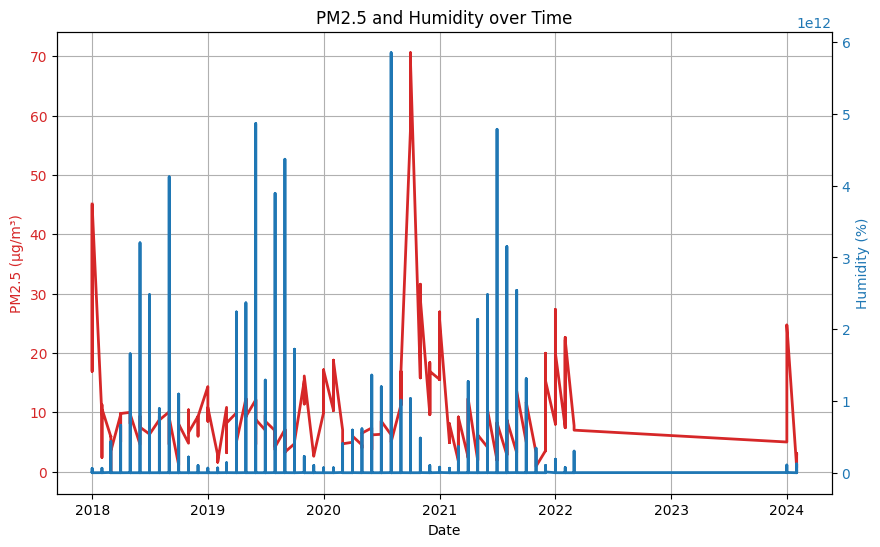

In [12]:
import matplotlib.pyplot as plt

# Query execution (you already have this part)
job_epa = client.query(query_filtered_epa)
results_epa = job_epa.result()

# Convert the results to a DataFrame
df_epa = results_epa.to_dataframe()

# Create the figure and axis for the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot PM2.5 on the primary y-axis (left)
ax1.plot(df_epa['date'], df_epa['pm25'], color='tab:red', label='PM2.5', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('PM2.5 (µg/m³)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Create a secondary y-axis for humidity
ax2 = ax1.twinx()
ax2.plot(df_epa['date'], df_epa['humidity'], color='tab:blue', label='Humidity', linewidth=2)
ax2.set_ylabel('Humidity (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and grid
plt.title('PM2.5 and Humidity over Time')
ax1.grid(True)

# Show the plot
plt.show()


In [13]:
# Pearson's correlation measures the strength and direction of the linear relationship
# between two variables. It's calculated based on the covariance of the variables
# and the standard deviations of each variable.
plt.show()

# Calculate Pearson correlation using the same DataFrame
correlation = df_epa['pm25'].corr(df_epa['humidity'])
print(f"Pearson correlation between PM2.5 and Humidity: {correlation:.3f}")

Pearson correlation between PM2.5 and Humidity: -0.003
